# Task 1: Correlation of Future Orientation Index and Gross Domestic Product
## Tasks

In this exercise, we try to reproduce the findings of the article “Quantifying the Advantage of Looking Forward” http://www.nature.com/articles/srep00350.

According to the study, the GDP per capita of countries is positively correlated to how much their population searches in Google for the next year, relative to how much they search for the previous year.

This ratio is called the Future Orientation Index (FOI). So for example for the year 2017 the FOI can be calculated as: FOI = number of searches for the term “2018” / number of searches for the term “2016”.

You will do the following tasks:
1. Aquire World Bank Data
2. Calculate the Future Orientation Index in Google Trends
3. Test the correlation between GDP and FOI

### Install requirements. 

The following cell contains all the necessary dependencies needed for this task. If you run the cell everything will be installed.  
* [`wbgapi`](https://github.com/tgherzog/wbgapi) is a Python package which provides modern, pythonic access to the World Bank's data API. [Here](https://github.com/tgherzog/wbgapi) is the documentation of `wbgapi`.
* [`pandas`](https://pandas.pydata.org/docs/index.html) is a Python package for creating and working with tabular data. [Here](https://pandas.pydata.org/docs/reference/index.html) is the documentation of `pandas`.
* [`matplotlib`](https://matplotlib.org/) is a Python package for creating plots. [Here](https://matplotlib.org/stable/api/index.html) is the documentation of `matplotlib`.
* [`scipy`](https://scipy.org/) is a Python package with different algorithms for scientific computing. [Here](https://docs.scipy.org/doc/scipy/reference/index.html#scipy-api) is the documentation of `scipy`.

In [2]:
! pip install wbgapi
! pip install pandas
! pip install matplotlib
! pip install scipy

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip


### Import requirements
The cell below imports all necessary dependancies. Make sure they are installed (see cell above).

In [3]:
import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

/Users/lorenz/uni/FoundationsOfCSS2025/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 1 World Bank Data
## 1.1 Download WDI data

From the WDI we need three indicators:
* Gross Domestic Product (GDP) per capita corrected by the Purchase Power Parity (PPP in current or 2005 international $, `"NY.GDP.PCAP.PP.KD"`)
* The amount of Internet users (per 100 people, `"IT.NET.USER.ZS"`
* The total population (described as as "Population, Total", `"SP.POP.TOTL"`)

In the following code chunk, download all data (including extras) for all countries in year 2014 and save it as a pandas data frame. See [here](https://github.com/tgherzog/wbgapi#accessing-data) how to use the `data` subpackage of `wbgapi`. 

Hint: To remove aggregates (economic regions defined by the World Bank) and include only countries, use `skipAggs=True`.  
You can also rename the columns to make it easier to use.

In [4]:
# Your Code goes here!
WDIdf = wb.data.DataFrame(['NY.GDP.PCAP.PP.KD', 'SP.POP.TOTL', 'IT.NET.USER.ZS'],
             labels = True,time=2014, skipAggs=True)

WDIdf = WDIdf.rename(columns={
    'NY.GDP.PCAP.PP.KD': 'GDP_per_capita_corrected_by_PPP',
    'SP.POP.TOTL': 'population_total',
    'IT.NET.USER.ZS': 'internet_users_per_100'
})
display(WDIdf.info())

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, ZWE to AFG
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          217 non-null    object 
 1   internet_users_per_100           201 non-null    float64
 2   GDP_per_capita_corrected_by_PPP  199 non-null    float64
 3   population_total                 217 non-null    float64
dtypes: float64(3), object(1)
memory usage: 16.6+ KB


None

Now drop any row that has `NaN` for this you can use `pandas` [`dropna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html) method.

In [5]:
# Your Code goes here!
WDIdf = WDIdf.dropna()
WDIdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 191 entries, ZWE to AFG
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          191 non-null    object 
 1   internet_users_per_100           191 non-null    float64
 2   GDP_per_capita_corrected_by_PPP  191 non-null    float64
 3   population_total                 191 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.5+ KB


Next we want to filter our data just for the countries that have more than 5 million Internet users because for countries with less, we think the data is not sufficient to make a good statement. Keep in Mind that the Internet Users are per 100 people, so don't forget to take the population into account.  
You can create a new column with the actual number of internet users and then filter based on that.

For example in the dataset Austria has 80.995825 internet users per 100 people, while 8546356 people living in Austria. This means Austria has 6922191.55 internet users in total. The calculation for that is as follows:
$
\begin{align}
internet\_users = population \cdot \frac{internet\_user\_per\_100}{100}
\end{align}
$


In [6]:
# Your Code goes here!
WDIdf['internet_users_total'] = WDIdf['population_total'] * (WDIdf['internet_users_per_100'] / 100)
WDIdf = WDIdf[WDIdf['internet_users_total'] > 5e6]
display(WDIdf)

,Country,internet_users_per_100,GDP_per_capita_corrected_by_PPP,population_total,internet_users_total
economy,,,,,
VNM,Viet Nam,41.0000,8751.882806,91679578.0,3.758863e+07
UZB,Uzbekistan,35.5000,7145.109807,30222994.0,1.072916e+07
USA,United States,73.0000,63018.803393,319257560.0,2.330580e+08
GBR,United Kingdom,91.6133,49250.559990,64620000.0,5.920051e+07
ARE,United Arab Emirates,90.4000,69409.037041,8059440.0,7.285734e+06
...,...,...,...,...,...
AUT,Austria,80.9958,60919.840708,8546356.0,6.922189e+06
AUS,Australia,84.0000,55288.115338,23475686.0,1.971958e+07
ARG,Argentina,64.7000,28200.815257,43024071.0,2.783657e+07


# 2 The Future Orientation Index in Google Trends
Now that we have the GDP for all countries with more than 5 million Internet users, we want to get the number of times they searched for the years 2013 and 2015.
## 2.1 Download data from Google Trends

You can download the data from Google Trends following these steps:

1) Log out from your google account or set its language to English

2) Go to trends.google.com and search for 2013 

3) Add 2015 as a search term

4) Select custom time rage: full year: 2014

5) Set the region to “Worldwide”. You can also try with this link (it links to the google trends page with all settings from above applied): https://trends.google.com/trends/explore?date=2014-01-01%202014-12-31&q=2013,2015

6) Go to the map at “Compared breakdown by region” and tick on “include low search volume regions”

7) On the top right menu click the download button to get a geoMap.csv file

If you have problems getting the file from the web interface, we also included it in the github repository.

Load the .csv file in a pandas data frame. Notice in the file the first 3 Lines are actually only information (while the third is the header). You can skip these lines by using `skiprows=3` in `pd.read_csv`. Set the headers to `"Country", "G2013", "G2015"`, this can be done by the keyword argument `names` in `pd.read_csv`.

Now remove again all rows containing `NaN`.

All the percentage data is saved as a string containing the `%` symbol. You can remove this with `pandas` [`str.replace`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html) method and save them as integer with `pandas` [`astype`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html) method. Do this for column `G2013` and `G2015`.


In [7]:
# Your Code goes here!
googleTrendsdf = pd.read_csv('geoMap.csv', skiprows=3, names=["Country", "G2013", "G2015"])
googleTrendsdf = googleTrendsdf.dropna()

googleTrendsdf['G2013'] = googleTrendsdf['G2013'].str.replace('%', '').astype(int)
googleTrendsdf['G2015'] = googleTrendsdf['G2015'].str.replace('%', '').astype(int)
display(googleTrendsdf)

,Country,G2013,G2015
0,Algeria,65,35
1,Moldova,87,13
2,Pakistan,85,15
3,Armenia,85,15
5,Kazakhstan,81,19
...,...,...,...
229,South Korea,70,30
230,Malawi,61,39
231,Taiwan,62,38
232,South Sudan,67,33


## 2.2 Calculate the Future Orientation Index

In the following code chunk, make a new column in the Google Trends dataframe with the Future Orientation Index, which is the ratio between the search volume for 2015 and 2013 in 2014 for each country

In [8]:
# Your Code goes here!
googleTrendsdf['future_orientation_index'] = googleTrendsdf['G2015'] / googleTrendsdf['G2013']


## 2.3 Merge with World Bank data

Merge the WDI and google trends data frames, using the name of the country. For this you can use `pandas` [`merge`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html) method.

In [9]:
# Your Code goes here!
mergedf = pd.merge(WDIdf, googleTrendsdf, on='Country')
display(mergedf)

,Country,internet_users_per_100,GDP_per_capita_corrected_by_PPP,population_total,internet_users_total,G2013,G2015,future_orientation_index
0,Uzbekistan,35.5000,7145.109807,3.022299e+07,1.072916e+07,72,28,0.388889
1,United States,73.0000,63018.803393,3.192576e+08,2.330580e+08,57,43,0.754386
2,United Kingdom,91.6133,49250.559990,6.462000e+07,5.920051e+07,53,47,0.886792
3,United Arab Emirates,90.4000,69409.037041,8.059440e+06,7.285734e+06,68,32,0.470588
4,Ukraine,46.2360,16978.812500,4.597238e+07,2.125579e+07,79,21,0.265823
5,Tunisia,46.1600,12823.988807,1.127429e+07,5.204211e+06,74,26,0.351351
6,Thailand,34.8861,18324.614467,7.021637e+07,2.449575e+07,73,27,0.369863
7,Switzerland,83.6173,76189.601844,8.188649e+06,6.847127e+06,53,47,0.886792
8,Sweden,92.5236,57085.385356,9.696110e+06,8.971190e+06,61,39,0.639344
9,Spain,76.1867,41339.411117,4.646073e+07,3.539690e+07,64,36,0.562500


# 3 Testing the correlation between GDP and FOI
# 3.1 Visualize FOI vs GDP

Now that you have the FOI index, GPD per capita and PPP value for each country, you can make a scatter plot of FOI vs GDP.

For this you can use the [`scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) method of `matplotlib`.

Text(0, 0.5, 'GDP per capita corrected by PPP')

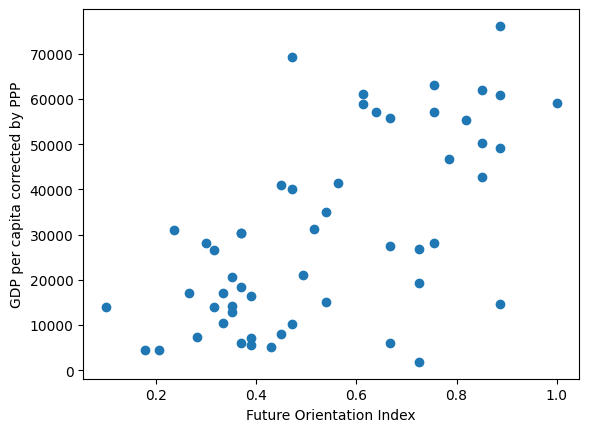

In [10]:
# Your Code goes here!
plt.scatter(mergedf['future_orientation_index'], mergedf['GDP_per_capita_corrected_by_PPP'])
plt.xlabel('Future Orientation Index')
plt.ylabel('GDP per capita corrected by PPP')

## 3.2 Measure Pearson’s correlation

In the following chunk, calculate Pearson’s correlation coefficient between GDP and FOI.

For this you can use the [`pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) method of `scipy`.  
Also write in a brief comment what this correlation coefficient means for the relationship of the future orientation and GDP of a country. 

In [11]:
# Your Code goes here!
correlation, p_value = stats.pearsonr(mergedf['future_orientation_index'], mergedf['GDP_per_capita_corrected_by_PPP'])
print(f'Pearson correlation coefficient: {correlation}, p-value: {p_value}')


Pearson correlation coefficient: 0.6262644707794084, p-value: 4.0835213946647984e-07


In [12]:
# Pearson correlation coefficient indicates a positive correlation between the Future Orientation Index and GDP per capita corrected by PPP. This number can tell us, if countries with a higher future orientation tend to have a higher GDP per capita. The number 0.626 suggests that there is some correleation between these metrics, but not a huge amount of it. 

# To learn more
### Check robustness
* What result do you get if you use other years? What if you choose one of the earliest years in Google trends?
* How do results change if you use a different threshod instead of 5 Million Internet users?
    
### Test other hypotheses
* Is future orientation generating wealth? Or is wealth enabling to look more to the future?
* Is the FOI really measuring orientation to the future? Could it be something else?

# Task 2: 

## Using Google Trends data to model Flu Trends

## Tasks
Google once proposed that they could predict flu waves using their search terms. We want to test if that's true. To achieve this, we use a dataset of Google search terms for flu and one for the flu cases in America. With those, we try to calculate a correlation between them.

### Install requirements. 

The following cell contains all the necessary dependencies needed for this task. If you run the cell everything will be installed.  
* [`pytrends`]((https://pypi.org/project/pytrends/)
* [`requests`]
* [`statsmodels`]

In [13]:
! pip install -U pytrends
! pip install requests
! pip install statsmodels

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip



## 1.1 Get weekly Google Trends data concerning the Flu/Influenza virus
Normally you could use the TrendReq class from the pytrends library to access google search trends. Because this can be unreliable, we already uploaded a dataset 'flu_interest_trends'  you can use instead. If you want, you can also try to get the data directly from the API.  
- Either read the `flu_interest_trends.csv` dataset and store it as a [pandas](https://pypi.org/project/pandas/) dataframe or request the data using the [TrendReq](https://github.com/GeneralMills/pytrends) class.

In [29]:
flu_interests= pd.read_csv('flu_interest_trends.csv')
display(flu_interests.head())
flu_interests.rename(columns={'/m/0cycc':'interest'}, inplace=True)
display(flu_interests.head())

,date,/m/0cycc,isPartial
0,2014-01-05,0,False
1,2014-01-12,0,False
2,2014-01-19,0,False
3,2014-01-26,0,False
4,2014-02-02,0,False


,date,interest,isPartial
0,2014-01-05,0,False
1,2014-01-12,0,False
2,2014-01-19,0,False
3,2014-01-26,0,False
4,2014-02-02,0,False


# 2 US National data

## Get data regarding the occurance of Influenza like Illnesses in the US

In the `Excercise 1` folder you will find a file named `ILINet.csv`, which contains data regarding the occurance of Influenza like Illnesses in the US. You can also find the data and the corresponding [documentation](https://gis.cdc.gov/grasp/fluview/FluViewPhase2QuickReferenceGuide.pdf) on the CDC's [FluView interactive dashboard](https://gis.cdc.gov/grasp/fluview/fluportaldashboard.html).
<br>
- Read the csv file, and store it as a [pandas](https://pypi.org/project/pandas/) dataframe. You might need to use the `skiprows` argument of the `read_csv` method to be able to load the data correctly.
- Select the columns named `YEAR`, `WEEK`, and `% WEIGHTED ILI` which will be needed for our analysis. Additionally, drop the rows which store observations from before 2014, or later than 2018.

In [62]:
# Your Code goes here!
illness_occurrences = pd.read_csv('ILINet.csv', header=1, usecols=['YEAR', 'WEEK', '% WEIGHTED ILI' ])
illness_occurrences = illness_occurrences[illness_occurrences['YEAR'] >= 2014]
illness_occurrences = illness_occurrences[illness_occurrences['YEAR'] <= 2018]
illness_occurrences.reset_index(inplace=True)
display(illness_occurrences.head())

,index,YEAR,WEEK,% WEIGHTED ILI
0,848,2014,1,4.28195
1,849,2014,2,3.56288
2,850,2014,3,3.36378
3,851,2014,4,3.39659
4,852,2014,5,3.11922


# 3 Testing the correlation between flu interest and US National data

# 3.1 Visualize flu interest vs US National data

Now that you have the US National data regarding the occurance of Influenza like Illnesses in the US, you can make a scatter plot of `flu interest` vs `% WEIGHTED ILI`.

For this you can use the [`scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) method of `matplotlib`.

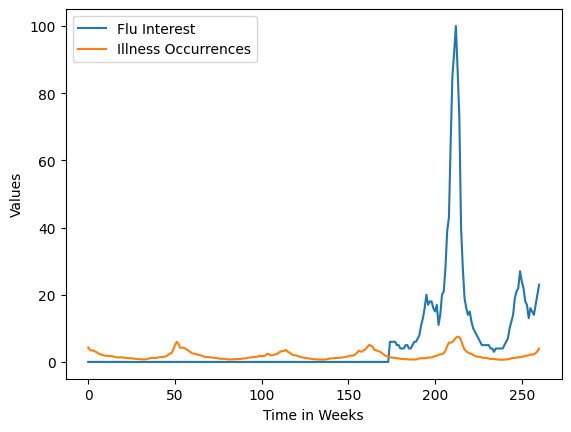

In [58]:
# Your Code goes here!
plt.plot(flu_interests['interest'])
plt.plot(illness_occurrences['% WEIGHTED ILI'])
plt.xlabel('Time in Weeks')
plt.ylabel('Values')
plt.legend(['Flu Interest', 'Illness Occurrences'])
plt.show()

## 3.2 Measure Pearson’s correlation

In the following chunk, calculate Pearson’s correlation coefficient between `flu interest` and `% WEIGHTED ILI`.

For this you can use the [`pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) method of `scipy`.

In [52]:
# Your Code goes here!
pearsonRResult = stats.pearsonr(flu_interests['interest'], illness_occurrences['% WEIGHTED ILI'])
print("pearson correlation coefficient:", pearsonRResult[0])

pearson correlation coefficient: 0.5599094962155893


## 3.3 Measure correlation after shuffling


Now we want to test if such a correlation could also appear by chance. For this, we shuffle the flue interest column and match it with a random search count. With that, we again calculate the correlation and compare it to the original.

For the shuffeling you can use `pandas` [`sample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html) method with `frac` set to 1.

This test shows you if the correlation could also happen by random chance.

In [59]:
# Your Code goes here!
flu_interests['shuffled_interest'] = flu_interests['interest'].sample(frac=1).reset_index(drop=True)
shuffledPearsonRResult = stats.pearsonr(flu_interests['shuffled_interest'], illness_occurrences['% WEIGHTED ILI'])
shuffledPearson, _ = stats.pearsonr(flu_interests['shuffled_interest'], illness_occurrences['% WEIGHTED ILI'])
print(shuffledPearson)
print("shuffled pearson correlation coefficient:", shuffledPearsonRResult[0])

-0.10021535600623
shuffled pearson correlation coefficient: -0.10021535600623


Repeat the calculation with 1000 permutations and plot the histogram of the resulting values. Add a line with the value of the correlation without permutation. Is it far or close to the permuted values?

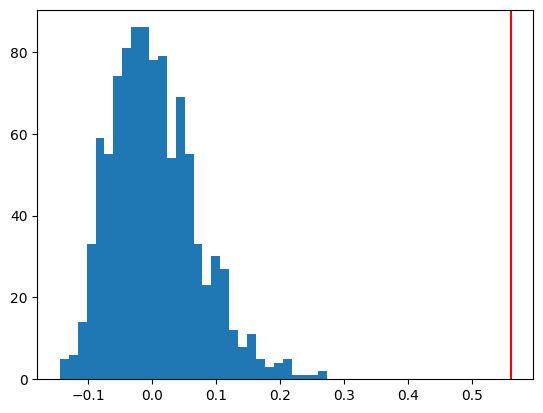

In [60]:
# Your Code goes here!
permutation_coefficients = []
for i in range(1000):
    shuffled_interest = flu_interests['interest'].sample(frac=1).reset_index(drop=True)
    shuffled_coefficients = stats.pearsonr(shuffled_interest, illness_occurrences['% WEIGHTED ILI'])
    permutation_coefficients.append(shuffled_coefficients[0])
plt.hist(permutation_coefficients, bins=30)
plt.axvline(pearsonRResult[0], color='red')

### Interpretation:
The correlation value for the original values are far from the bell curve produced by the random shuffling, which seems to give some significance to the correlation as random shuffling is clearly not able to replicate it.
But still, the orignal plots show that this has to be used with caution.

### To learn more

#### Prediction
* Download the Google Trends data for 2019, and use your models to predict the values of `% WEIGHTED ILI`.
* Do the models make good predictions? Which model performs better?